In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import sympy as sp
from sympy.abc import k, t, s, v 

\begin{align}
v = \frac{\mathrm{d}P}{\mathrm{d}t} = \frac{v_\max S}{k_M + S} &\simeq -\frac{\mathrm{d}S}{\mathrm{d}t} \\
\Leftrightarrow\int\limits_{S_0}^S \frac{k_M + S}{S} \mathrm{d}S &= -\int\limits_0^t v_\max t\mathrm{d}t \\
\Leftrightarrow\left[k_M\ln(S) + S\right]_{S_0}^S &= \left[- v_\max t\right]_0^t \\
\Leftrightarrow\ln\left(\frac{S}{S_0}\right) + \frac{S - S_0}{k_M} &= -\frac{v_\max t}{k_M} \\
\Leftrightarrow\frac{S}{k_M} \exp\left(\frac{S}{k_M}\right) &= \frac{S_0}{k_M}\exp\left(\frac{S_0 - v_\max t}{k_M}\right) \\
\Leftrightarrow S &= k_M W_0 \left[\frac{S_0}{k_M}\exp\left(\frac{S_0 - v_\max t}{k_M}\right)\right]
\end{align}

In [13]:
def S(t, S0, vmax, kM):
    return np.real(kM * special.lambertw(S0 / kM * np.exp((S0 - vmax * t) / kM)))

In [20]:
t = np.linspace(0, 10000, 200)

In [21]:
vmax = 1e-9
kM = 0.11

In [22]:
S0 = 0.5

In [23]:
s = S(t, S0, vmax, kM)

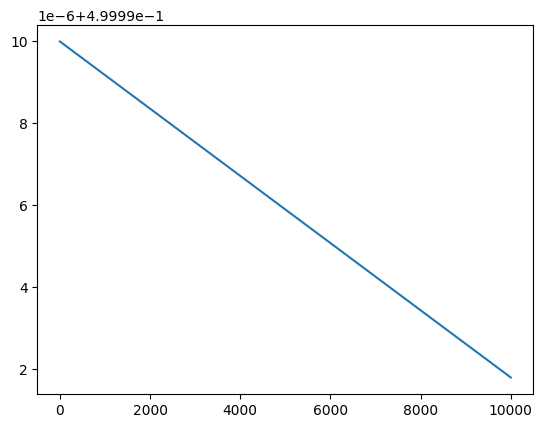

In [24]:
fig, axe = plt.subplots()
axe.plot(t, s)

In [4]:
s0 = sp.Symbol("s0")

In [15]:
h1 = sp.integrate((k + s) / s, (s, s0, s))
h2 = sp.integrate(-v, (t, 0, t))

In [16]:
h1

k*log(s) - k*log(s0) + s - s0

In [17]:
h2

-t*v

In [21]:
sol = sp.solve(sp.Eq(h1, h2), s)
sol

[k*LambertW(s0*exp((s0 - t*v)/k)/k)]

In [20]:
sol[0]

k*LambertW(s0*exp((s0 - t*v)/k)/k)